In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import os

# Chemins
DATA_PATH = "../data/processed/dataset_final.csv"
FIGURES_PATH = "../reports/figures/eda"
REPORTS_PATH = "../reports/eda"

# Création des dossiers
os.makedirs(FIGURES_PATH, exist_ok=True)
os.makedirs(REPORTS_PATH, exist_ok=True)

# Chargement du dataset
df = pd.read_csv(DATA_PATH)

# Conversion des dates
df["date_vente"] = pd.to_datetime(
    df["date_vente"],
    errors="coerce"
)

df["date_mois"] = pd.to_datetime(
    df["date_mois"],
    errors="coerce"
)

print("Dataset chargé avec succès")
print("Dimensions :", df.shape)

df.head()

Dataset chargé avec succès
Dimensions : (28451, 24)


,transaction_id,date_vente,categorie_produit_1,categorie_produit_2,produit,quantite_vendue,trans_amount_weight,region,pays,code_pays,...,inflation,gdp_growth,temperature,precipitation,interest_rate,wheat_price,corn_price,soybean_price,trimestre,jour_semaine
0,319041,2007-01-03,agriculture,soil & crop treatment,sprayer (self propelled),8.0,24.0,Northern America,united states,USA,...,2.852672,2.003858,-2.735484,0.632258,5.32,172.566631,165.160019,255.867379,1,2
1,319042,2007-01-03,agriculture,soil & crop treatment,sprayer (self propelled),4.0,12.0,Northern America,united states,USA,...,2.852672,2.003858,-2.735484,0.632258,5.32,172.566631,165.160019,255.867379,1,2
2,319043,2007-01-03,agriculture,soil & crop treatment,sprayer (self propelled),10.0,30.0,Northern America,united states,USA,...,2.852672,2.003858,-2.735484,0.632258,5.32,172.566631,165.160019,255.867379,1,2
3,319103,2007-01-03,agriculture,soil & crop treatment,sprayer (self propelled),1.0,3.0,Northern America,united states,USA,...,2.852672,2.003858,-2.735484,0.632258,5.32,172.566631,165.160019,255.867379,1,2
4,319128,2007-01-03,agriculture,soil & crop treatment,sprayer (self propelled),1.0,4.0,Northern America,united states,USA,...,2.852672,2.003858,-2.735484,0.632258,5.32,172.566631,165.160019,255.867379,1,2


In [2]:
print("Dimensions du dataset :", df.shape)

print("\nTypes des colonnes :")
print(df.dtypes)

print("\nValeurs manquantes :")
print(df.isnull().sum())

print("\nPériode couverte :")
print("Date minimum :", df["date_vente"].min())
print("Date maximum :", df["date_vente"].max())

print("\nNombre de produits :", df["produit"].nunique())
print("Nombre de régions :", df["region"].nunique())
print("Nombre de pays :", df["pays"].nunique())

print("\nSecteur :", df["categorie_produit_1"].unique())
print("Région :", df["region"].unique())
print("Pays :", df["code_pays"].unique())

Dimensions du dataset : (28451, 24)

Types des colonnes :
transaction_id                  int64
date_vente             datetime64[ns]
categorie_produit_1            object
categorie_produit_2            object
produit                        object
quantite_vendue               float64
trans_amount_weight           float64
region                         object
pays                           object
code_pays                      object
devise                         object
annee                           int64
mois                            int64
date_mois              datetime64[ns]
inflation                     float64
gdp_growth                    float64
temperature                   float64
precipitation                 float64
interest_rate                 float64
wheat_price                   float64
corn_price                    float64
soybean_price                 float64
trimestre                       int64
jour_semaine                    int64
dtype: object

Valeurs manquan

In [3]:
# Calcul des KPI
kpi_summary = {
    "nombre_lignes": len(df),
    "nombre_produits": df["produit"].nunique(),
    "nombre_categories_niveau_1": df["categorie_produit_1"].nunique(),
    "nombre_categories_niveau_2": df["categorie_produit_2"].nunique(),
    "nombre_regions": df["region"].nunique(),
    "nombre_pays": df["pays"].nunique(),
    "quantite_totale_vendue": df["quantite_vendue"].sum(),
    "quantite_moyenne_vendue": df["quantite_vendue"].mean(),
    "montant_total": df["trans_amount_weight"].sum(),
    "montant_moyen": df["trans_amount_weight"].mean(),
    "date_min": df["date_vente"].min(),
    "date_max": df["date_vente"].max()
}

kpi_df = pd.DataFrame([kpi_summary])

kpi_df.to_csv(
    f"{REPORTS_PATH}/kpi_summary.csv",
    index=False
)

kpi_df

,nombre_lignes,nombre_produits,nombre_categories_niveau_1,nombre_categories_niveau_2,nombre_regions,nombre_pays,quantite_totale_vendue,quantite_moyenne_vendue,montant_total,montant_moyen,date_min,date_max
0,28451,32,1,7,1,2,142628.0,5.01311,1038383.0,36.497241,2007-01-03,2016-12-22


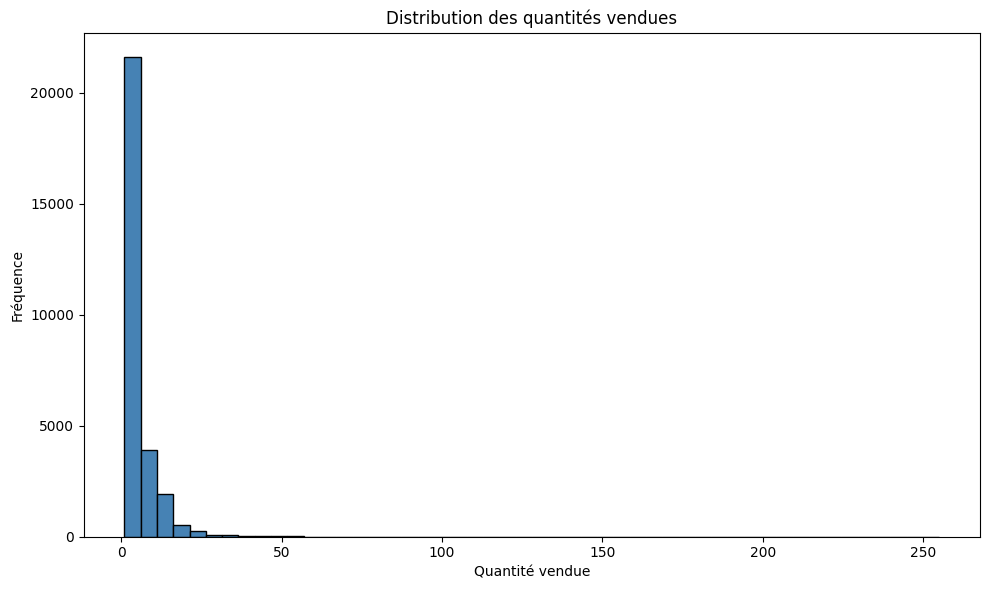

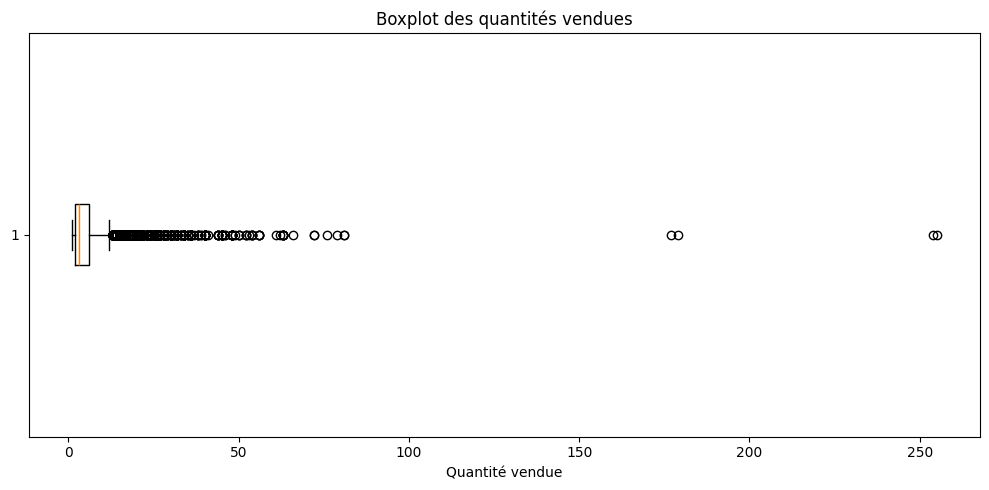

,quantite_vendue,trans_amount_weight
count,28451.000000,28451.000000
mean,5.013110,36.497241
std,5.993336,65.908221
min,1.000000,1.000000
25%,2.000000,6.000000
50%,3.000000,17.000000
75%,6.000000,42.000000
max,255.000000,1377.000000


In [4]:
# Distribution des quantités vendues

plt.figure(figsize=(10, 6))

plt.hist(
    df["quantite_vendue"],
    bins=50,
    color="steelblue",
    edgecolor="black"
)

plt.title("Distribution des quantités vendues")
plt.xlabel("Quantité vendue")
plt.ylabel("Fréquence")
plt.tight_layout()

plt.savefig(
    f"{FIGURES_PATH}/distribution_quantite.png"
)

plt.show()

# Boxplot des quantités vendues

plt.figure(figsize=(10, 5))

plt.boxplot(
    df["quantite_vendue"],
    vert=False
)

plt.title("Boxplot des quantités vendues")
plt.xlabel("Quantité vendue")
plt.tight_layout()

plt.savefig(
    f"{FIGURES_PATH}/boxplot_quantite.png"
)

plt.show()

# Statistiques descriptives

df[
    [
        "quantite_vendue",
        "trans_amount_weight"
    ]
].describe()

In [5]:
# Analyse des valeurs atypiques

Q1 = df["quantite_vendue"].quantile(0.25)
Q3 = df["quantite_vendue"].quantile(0.75)

IQR = Q3 - Q1

borne_inf = Q1 - 1.5 * IQR
borne_sup = Q3 + 1.5 * IQR

outliers = df[
    (df["quantite_vendue"] < borne_inf)
    |
    (df["quantite_vendue"] > borne_sup)
]

pourcentage_outliers = (
    len(outliers) / len(df) * 100
)

print("Q1 :", Q1)
print("Q3 :", Q3)
print("IQR :", IQR)
print("Borne inférieure :", borne_inf)
print("Borne supérieure :", borne_sup)
print("Nombre de valeurs atypiques :", len(outliers))
print("Pourcentage :", round(pourcentage_outliers, 2), "%")

print(
    "\nLes valeurs atypiques sont conservées, "
    "car elles peuvent représenter de grandes commandes."
)

outliers[
    [
        "date_vente",
        "produit",
        "quantite_vendue",
        "region",
        "pays"
    ]
].head()

Q1 : 2.0
Q3 : 6.0
IQR : 4.0
Borne inférieure : -4.0
Borne supérieure : 12.0
Nombre de valeurs atypiques : 1929
Pourcentage : 6.78 %

Les valeurs atypiques sont conservées, car elles peuvent représenter de grandes commandes.


,date_vente,produit,quantite_vendue,region,pays
177,2007-02-27,combine harvester (cereals) & cotton picker,17.0,Northern America,united states
225,2007-03-15,combine harvester (cereals) & cotton picker,20.0,Northern America,united states
226,2007-03-15,combine harvester (cereals) & cotton picker,20.0,Northern America,united states
254,2007-03-22,combine harvester (cereals) & cotton picker,16.0,Northern America,united states
255,2007-03-22,combine harvester (cereals) & cotton picker,16.0,Northern America,united states


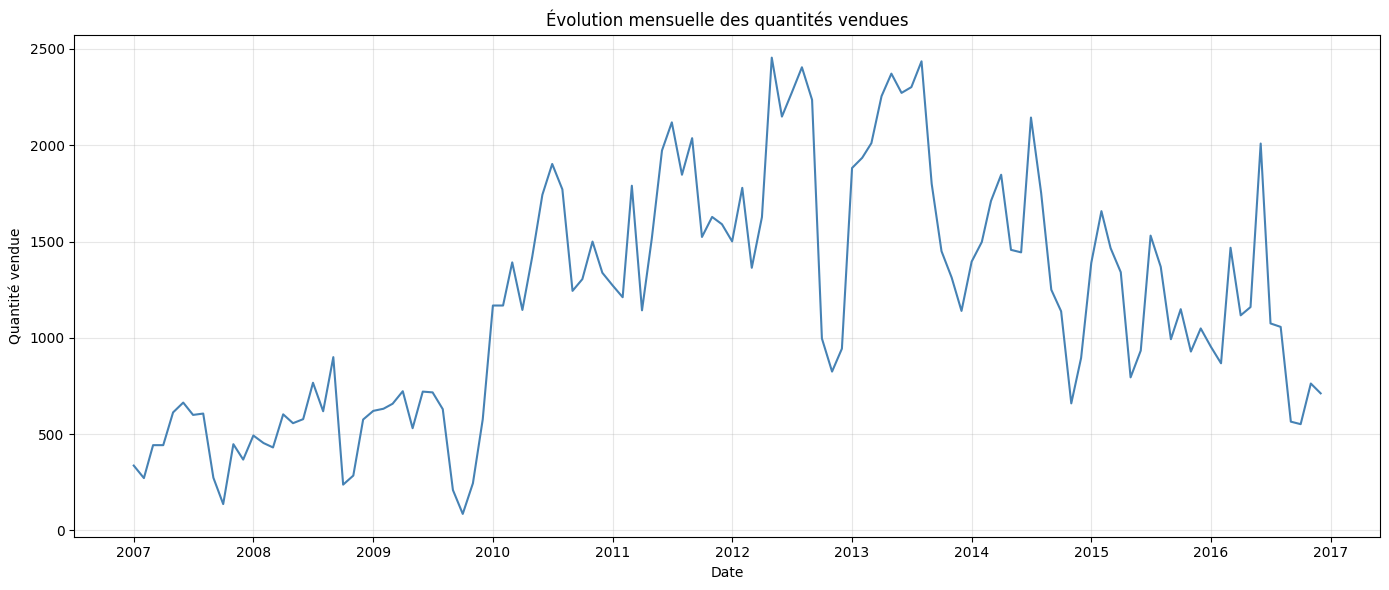

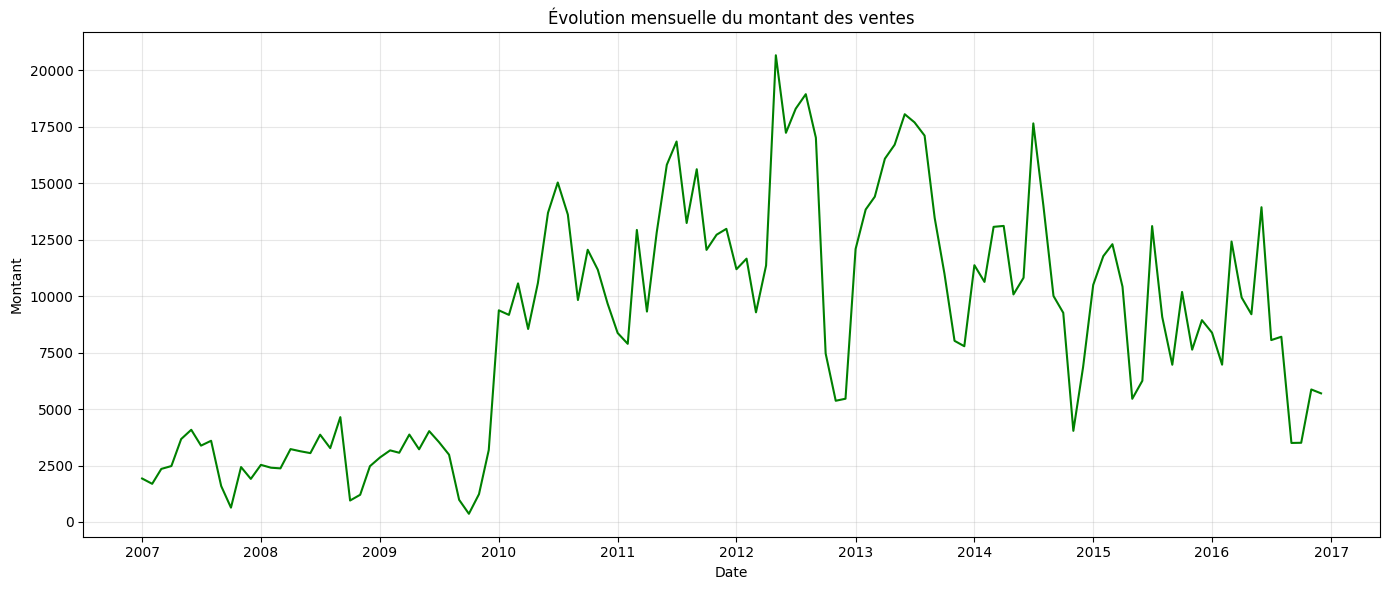

,annee,mois,quantite_vendue,trans_amount_weight,date
0,2007,1,337.0,1925.0,2007-01-01
1,2007,2,272.0,1690.0,2007-02-01
2,2007,3,443.0,2350.0,2007-03-01
3,2007,4,443.0,2477.0,2007-04-01
4,2007,5,613.0,3672.0,2007-05-01


In [6]:
# Évolution mensuelle des ventes

monthly_sales = (
    df
    .groupby(
        ["annee", "mois"],
        as_index=False
    )
    .agg({
        "quantite_vendue": "sum",
        "trans_amount_weight": "sum"
    })
)

monthly_sales["date"] = pd.to_datetime(
    monthly_sales["annee"].astype(str)
    + "-"
    + monthly_sales["mois"].astype(str)
    + "-01"
)

monthly_sales = monthly_sales.sort_values("date")

monthly_sales.to_csv(
    f"{REPORTS_PATH}/monthly_sales.csv",
    index=False
)

# Évolution mensuelle des quantités

plt.figure(figsize=(14, 6))

plt.plot(
    monthly_sales["date"],
    monthly_sales["quantite_vendue"],
    color="steelblue"
)

plt.title("Évolution mensuelle des quantités vendues")
plt.xlabel("Date")
plt.ylabel("Quantité vendue")
plt.grid(alpha=0.3)
plt.tight_layout()

plt.savefig(
    f"{FIGURES_PATH}/evolution_quantite_mensuelle.png"
)

plt.show()

# Évolution mensuelle du montant

plt.figure(figsize=(14, 6))

plt.plot(
    monthly_sales["date"],
    monthly_sales["trans_amount_weight"],
    color="green"
)

plt.title("Évolution mensuelle du montant des ventes")
plt.xlabel("Date")
plt.ylabel("Montant")
plt.grid(alpha=0.3)
plt.tight_layout()

plt.savefig(
    f"{FIGURES_PATH}/evolution_montant_mensuel.png"
)

plt.show()

monthly_sales.head()

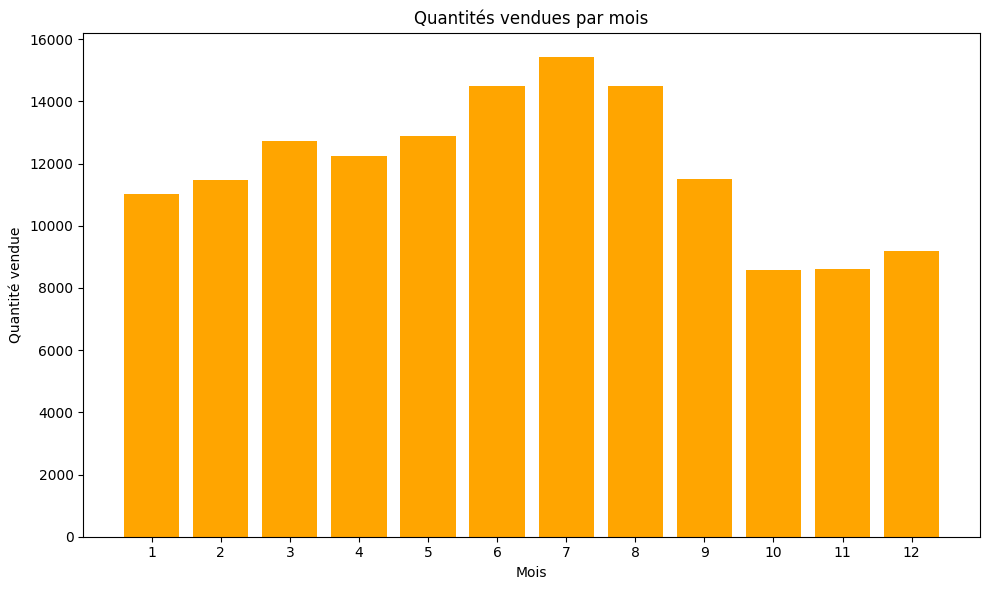

,mois,quantite_vendue,trans_amount_weight
0,1,11014.0,78568.0
1,2,11475.0,79171.0
2,3,12734.0,92743.0
3,4,12244.0,88336.0
4,5,12878.0,95510.0
5,6,14487.0,106931.0
6,7,15431.0,117443.0
7,8,14494.0,104015.0
8,9,11509.0,83594.0
9,10,8576.0,67450.0


In [7]:
# Saisonnalité des ventes

sales_by_month = (
    df
    .groupby(
        "mois",
        as_index=False
    )
    .agg({
        "quantite_vendue": "sum",
        "trans_amount_weight": "sum"
    })
)

sales_by_month.to_csv(
    f"{REPORTS_PATH}/sales_by_month.csv",
    index=False
)

plt.figure(figsize=(10, 6))

plt.bar(
    sales_by_month["mois"],
    sales_by_month["quantite_vendue"],
    color="orange"
)

plt.title("Quantités vendues par mois")
plt.xlabel("Mois")
plt.ylabel("Quantité vendue")
plt.xticks(range(1, 13))
plt.tight_layout()

plt.savefig(
    f"{FIGURES_PATH}/ventes_par_mois.png"
)

plt.show()

sales_by_month

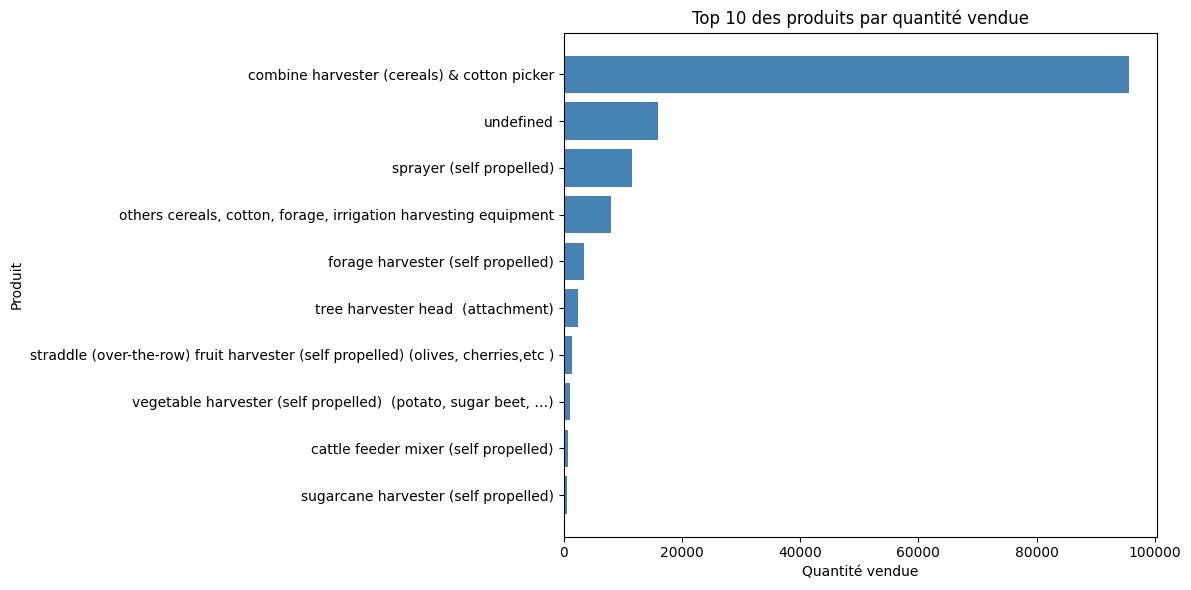

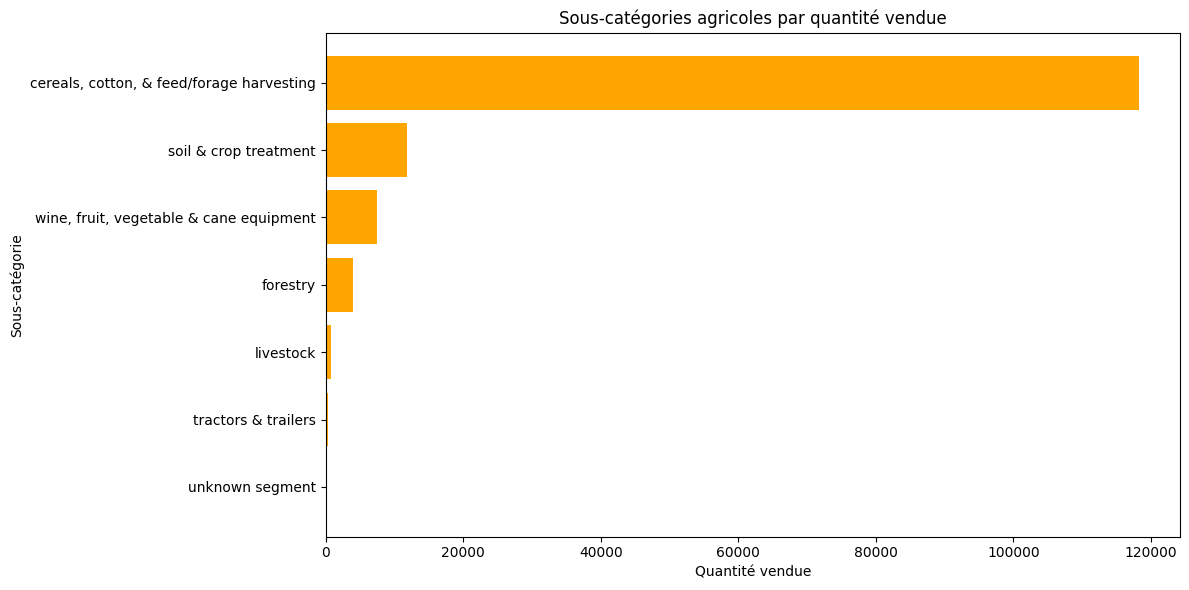

,produit,quantite_vendue,trans_amount_weight
5,combine harvester (cereals) & cotton picker,95598.0,718028.0
28,undefined,15875.0,96836.0
17,sprayer (self propelled),11555.0,44525.0
14,"others cereals, cotton, forage, irrigation har...",7948.0,73227.0
7,forage harvester (self propelled),3427.0,46532.0
25,tree harvester head (attachment),2487.0,22059.0
20,straddle (over-the-row) fruit harvester (self ...,1404.0,10375.0
30,"vegetable harvester (self propelled) (potato,...",1010.0,3035.0
3,cattle feeder mixer (self propelled),665.0,1532.0
22,sugarcane harvester (self propelled),574.0,6346.0


In [8]:
# Analyse des produits et sous-catégories

top_products = (
    df
    .groupby(
        "produit",
        as_index=False
    )
    .agg({
        "quantite_vendue": "sum",
        "trans_amount_weight": "sum"
    })
    .sort_values(
        "quantite_vendue",
        ascending=False
    )
    .head(10)
)

top_products.to_csv(
    f"{REPORTS_PATH}/top_products.csv",
    index=False
)

plt.figure(figsize=(12, 6))

plt.barh(
    top_products["produit"],
    top_products["quantite_vendue"],
    color="steelblue"
)

plt.title("Top 10 des produits par quantité vendue")
plt.xlabel("Quantité vendue")
plt.ylabel("Produit")
plt.gca().invert_yaxis()
plt.tight_layout()

plt.savefig(
    f"{FIGURES_PATH}/top10_produits.png"
)

plt.show()

# Analyse des sous-catégories agricoles

top_categories = (
    df
    .groupby(
        "categorie_produit_2",
        as_index=False
    )
    .agg({
        "quantite_vendue": "sum",
        "trans_amount_weight": "sum"
    })
    .sort_values(
        "quantite_vendue",
        ascending=False
    )
    .head(10)
)

top_categories.to_csv(
    f"{REPORTS_PATH}/top_categories.csv",
    index=False
)

plt.figure(figsize=(12, 6))

plt.barh(
    top_categories["categorie_produit_2"],
    top_categories["quantite_vendue"],
    color="orange"
)

plt.title("Sous-catégories agricoles par quantité vendue")
plt.xlabel("Quantité vendue")
plt.ylabel("Sous-catégorie")
plt.gca().invert_yaxis()
plt.tight_layout()

plt.savefig(
    f"{FIGURES_PATH}/top10_categories.png"
)

plt.show()

top_products

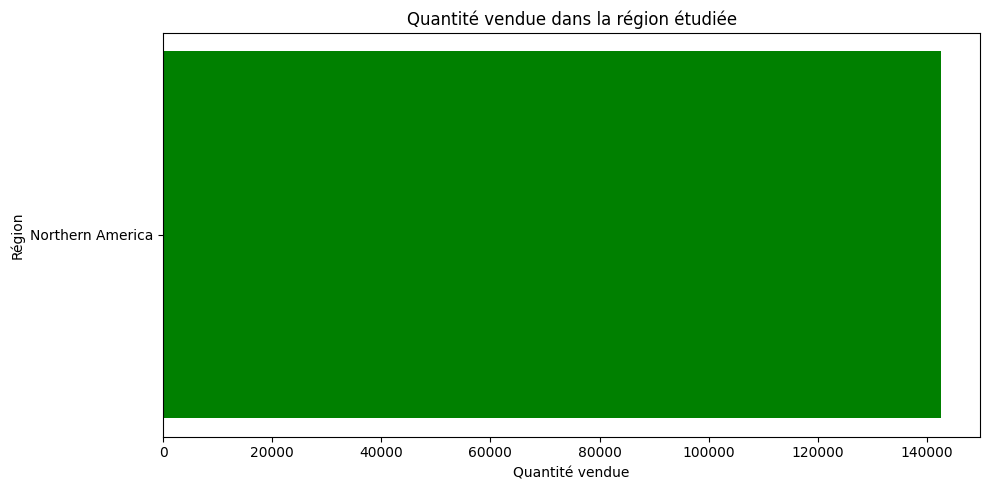

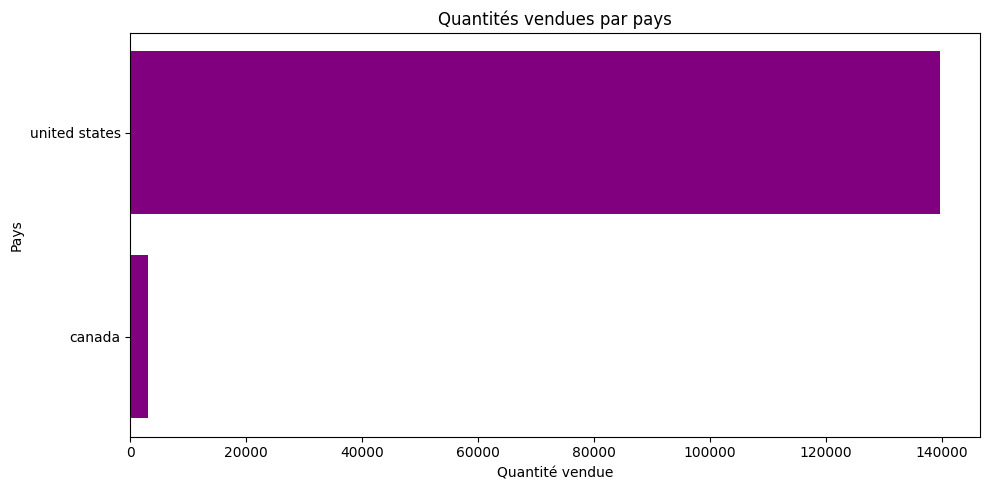

(             region  quantite_vendue  trans_amount_weight
 0  Northern America         142628.0            1038383.0,
             pays  quantite_vendue  trans_amount_weight
 1  united states         139558.0            1014849.0
 0         canada           3070.0              23534.0)

In [9]:
# Analyse géographique

top_regions = (
    df
    .groupby(
        "region",
        as_index=False
    )
    .agg({
        "quantite_vendue": "sum",
        "trans_amount_weight": "sum"
    })
    .sort_values(
        "quantite_vendue",
        ascending=False
    )
)

top_regions.to_csv(
    f"{REPORTS_PATH}/top_regions.csv",
    index=False
)

plt.figure(figsize=(10, 5))

plt.barh(
    top_regions["region"],
    top_regions["quantite_vendue"],
    color="green"
)

plt.title("Quantité vendue dans la région étudiée")
plt.xlabel("Quantité vendue")
plt.ylabel("Région")
plt.gca().invert_yaxis()
plt.tight_layout()

plt.savefig(
    f"{FIGURES_PATH}/top10_regions.png"
)

plt.show()

# Analyse par pays

top_countries = (
    df
    .groupby(
        "pays",
        as_index=False
    )
    .agg({
        "quantite_vendue": "sum",
        "trans_amount_weight": "sum"
    })
    .sort_values(
        "quantite_vendue",
        ascending=False
    )
)

top_countries.to_csv(
    f"{REPORTS_PATH}/top_countries.csv",
    index=False
)

plt.figure(figsize=(10, 5))

plt.barh(
    top_countries["pays"],
    top_countries["quantite_vendue"],
    color="purple"
)

plt.title("Quantités vendues par pays")
plt.xlabel("Quantité vendue")
plt.ylabel("Pays")
plt.gca().invert_yaxis()
plt.tight_layout()

plt.savefig(
    f"{FIGURES_PATH}/top10_pays.png"
)

plt.show()

top_regions, top_countries

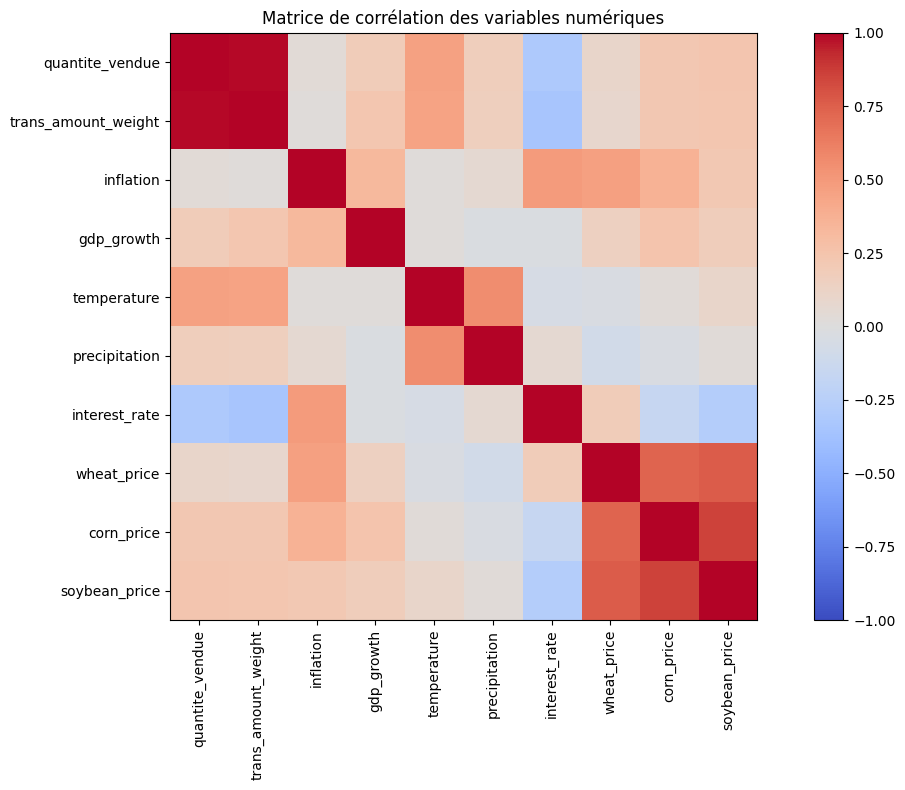

,quantite_vendue,trans_amount_weight,inflation,gdp_growth,temperature,precipitation,interest_rate,wheat_price,corn_price,soybean_price
quantite_vendue,1.000000,0.990953,0.033734,0.182242,0.453613,0.166020,-0.309180,0.099687,0.222910,0.236399
trans_amount_weight,0.990953,1.000000,0.021691,0.227060,0.447425,0.157570,-0.340944,0.080725,0.223551,0.231081
inflation,0.033734,0.021691,1.000000,0.325183,0.017633,0.056016,0.486245,0.468545,0.365077,0.212702
gdp_growth,0.182242,0.227060,0.325183,1.000000,0.022896,-0.029491,-0.029586,0.141174,0.246920,0.178632
temperature,0.453613,0.447425,0.017633,0.022896,1.000000,0.556229,-0.049311,-0.038047,0.024650,0.098822
precipitation,0.166020,0.157570,0.056016,-0.029491,0.556229,1.000000,0.055691,-0.085847,-0.035350,0.030747
interest_rate,-0.309180,-0.340944,0.486245,-0.029586,-0.049311,0.055691,1.000000,0.179824,-0.160989,-0.269235
wheat_price,0.099687,0.080725,0.468545,0.141174,-0.038047,-0.085847,0.179824,1.000000,0.731527,0.765124
corn_price,0.222910,0.223551,0.365077,0.246920,0.024650,-0.035350,-0.160989,0.731527,1.000000,0.851876
soybean_price,0.236399,0.231081,0.212702,0.178632,0.098822,0.030747,-0.269235,0.765124,0.851876,1.000000


In [10]:
# Matrice de corrélation
# Agrégation mensuelle par pays

monthly_corr = (
    df
    .groupby(
        ["annee", "mois", "code_pays"],
        as_index=False
    )
    .agg({
        "quantite_vendue": "sum",
        "trans_amount_weight": "sum",
        "inflation": "mean",
        "gdp_growth": "mean",
        "temperature": "mean",
        "precipitation": "mean",
        "interest_rate": "mean",
        "wheat_price": "mean",
        "corn_price": "mean",
        "soybean_price": "mean"
    })
)

numeric_features = [
    "quantite_vendue",
    "trans_amount_weight",
    "inflation",
    "gdp_growth",
    "temperature",
    "precipitation",
    "interest_rate",
    "wheat_price",
    "corn_price",
    "soybean_price"
]

corr_matrix = monthly_corr[
    numeric_features
].corr()

corr_matrix.to_csv(
    f"{REPORTS_PATH}/correlation_matrix.csv"
)

plt.figure(figsize=(12, 8))

plt.imshow(
    corr_matrix,
    cmap="coolwarm",
    vmin=-1,
    vmax=1
)

plt.colorbar()

plt.xticks(
    range(len(corr_matrix.columns)),
    corr_matrix.columns,
    rotation=90
)

plt.yticks(
    range(len(corr_matrix.columns)),
    corr_matrix.columns
)

plt.title("Matrice de corrélation des variables numériques")
plt.tight_layout()

plt.savefig(
    f"{FIGURES_PATH}/correlation_heatmap.png"
)

plt.show()

corr_matrix

In [11]:
resume = f"""

Nombre total de lignes : {len(df)}
Nombre de colonnes : {df.shape[1]}
Période étudiée : de {df['date_vente'].min()} à {df['date_vente'].max()}

Nombre de produits : {df['produit'].nunique()}
Nombre de catégories niveau 1 : {df['categorie_produit_1'].nunique()}
Nombre de régions : {df['region'].nunique()}
Nombre de pays : {df['pays'].nunique()}

Quantité totale vendue : {df['quantite_vendue'].sum()}
Montant total des ventes : {df['trans_amount_weight'].sum()}

Produit le plus vendu : {top_products.iloc[0]['produit']}
Région la plus active : {top_regions.iloc[0]['region']}

"""

with open("../reports/eda/eda_resume.txt", "w", encoding="utf-8") as f:
    f.write(resume)

print(resume)



Nombre total de lignes : 28451
Nombre de colonnes : 24
Période étudiée : de 2007-01-03 00:00:00 à 2016-12-22 00:00:00

Nombre de produits : 32
Nombre de catégories niveau 1 : 1
Nombre de régions : 1
Nombre de pays : 2

Quantité totale vendue : 142628.0
Montant total des ventes : 1038383.0

Produit le plus vendu : combine harvester (cereals) & cotton picker
Région la plus active : Northern America




In [12]:
expected_files = [
    f"{REPORTS_PATH}/kpi_summary.csv",
    f"{REPORTS_PATH}/monthly_sales.csv",
    f"{REPORTS_PATH}/sales_by_month.csv",
    f"{REPORTS_PATH}/top_products.csv",
    f"{REPORTS_PATH}/top_categories.csv",
    f"{REPORTS_PATH}/top_regions.csv",
    f"{REPORTS_PATH}/top_countries.csv",
    f"{REPORTS_PATH}/correlation_matrix.csv",
    f"{REPORTS_PATH}/eda_resume.txt",
    f"{FIGURES_PATH}/distribution_quantite.png",
    f"{FIGURES_PATH}/boxplot_quantite.png",
    f"{FIGURES_PATH}/evolution_quantite_mensuelle.png",
    f"{FIGURES_PATH}/evolution_montant_mensuel.png",
    f"{FIGURES_PATH}/ventes_par_mois.png",
    f"{FIGURES_PATH}/top10_produits.png",
    f"{FIGURES_PATH}/top10_categories.png",
    f"{FIGURES_PATH}/top10_regions.png",
    f"{FIGURES_PATH}/top10_pays.png",
    f"{FIGURES_PATH}/correlation_heatmap.png"
]

for file in expected_files:
    print(file, os.path.exists(file))

../reports/eda/kpi_summary.csv True
../reports/eda/monthly_sales.csv True
../reports/eda/sales_by_month.csv True
../reports/eda/top_products.csv True
../reports/eda/top_categories.csv True
../reports/eda/top_regions.csv True
../reports/eda/top_countries.csv True
../reports/eda/correlation_matrix.csv True
../reports/eda/eda_resume.txt True
../reports/figures/eda/distribution_quantite.png True
../reports/figures/eda/boxplot_quantite.png True
../reports/figures/eda/evolution_quantite_mensuelle.png True
../reports/figures/eda/evolution_montant_mensuel.png True
../reports/figures/eda/ventes_par_mois.png True
../reports/figures/eda/top10_produits.png True
../reports/figures/eda/top10_categories.png True
../reports/figures/eda/top10_regions.png True
../reports/figures/eda/top10_pays.png True
../reports/figures/eda/correlation_heatmap.png True
